In [15]:
import pandas as pd
import numpy as np
# import plotly.graph_objects as go
import os

# Set data directory
data_dir = '../data/'

In [29]:


# ... (your existing setup) ...
years = [2020, 2021, 2022, 2023, 2024]
jawa = ['JAWA BARAT', 'JAWA TENGAH', 'JAWA TIMUR', 'DKI JAKARTA', 'BANTEN', 'DI YOGYAKARTA'] # added DI Yogyakarta for completeness
data_dir = '../data' # update this to your path

processed_dfs = []

for year in years:
    file_path = os.path.join(data_dir, f'ppo_indonesia_{year}.csv')
    
    # Read the file normally
    df = pd.read_csv(file_path, skiprows=4)
    
    # FIX: Select only the first 3 columns regardless of how many exist
    # column 0: Provinsi, column 1: Semester 1, column 2: Semester 2
    df = df.iloc[:, [0, 1, 2]]
    
    # Now we can safely rename because we only have 3 columns
    df.columns = ['Provinsi', 'S1', 'S2']
    
    # Clean up names (remove trailing/leading spaces which are common in BPS data)
    df['Provinsi'] = df['Provinsi'].str.strip()
    
    # Filter for Jawa
    df = df[df['Provinsi'].isin(jawa)].copy()
    
    # Convert to numeric
    df['S1'] = pd.to_numeric(df['S1'], errors='coerce')
    df['S2'] = pd.to_numeric(df['S2'], errors='coerce')
    
    # Fallback logic: Semester 2, if NaN then Semester 1
    df[f'{year}'] = df['S2'].fillna(df['S1'])
    
    processed_dfs.append(df[['Provinsi', f'{year}']])

final_comparison = processed_dfs[0]
for df in processed_dfs[1:]:
    final_comparison = pd.merge(final_comparison, df, on='Provinsi', how='outer')

print(final_comparison)

        Provinsi   2020   2021   2022   2023   2024
0         BANTEN   5.85   6.04   5.89   6.00   5.57
1  DI YOGYAKARTA  12.17  11.20  10.64  10.27  10.11
2    DKI JAKARTA   4.69   4.67   4.61   4.44   4.14
3     JAWA BARAT   7.79   7.48   7.52   7.19   6.65
4    JAWA TENGAH  10.57  10.16  10.02   9.78   8.83
5     JAWA TIMUR   8.37   7.99   7.78   7.50   6.83


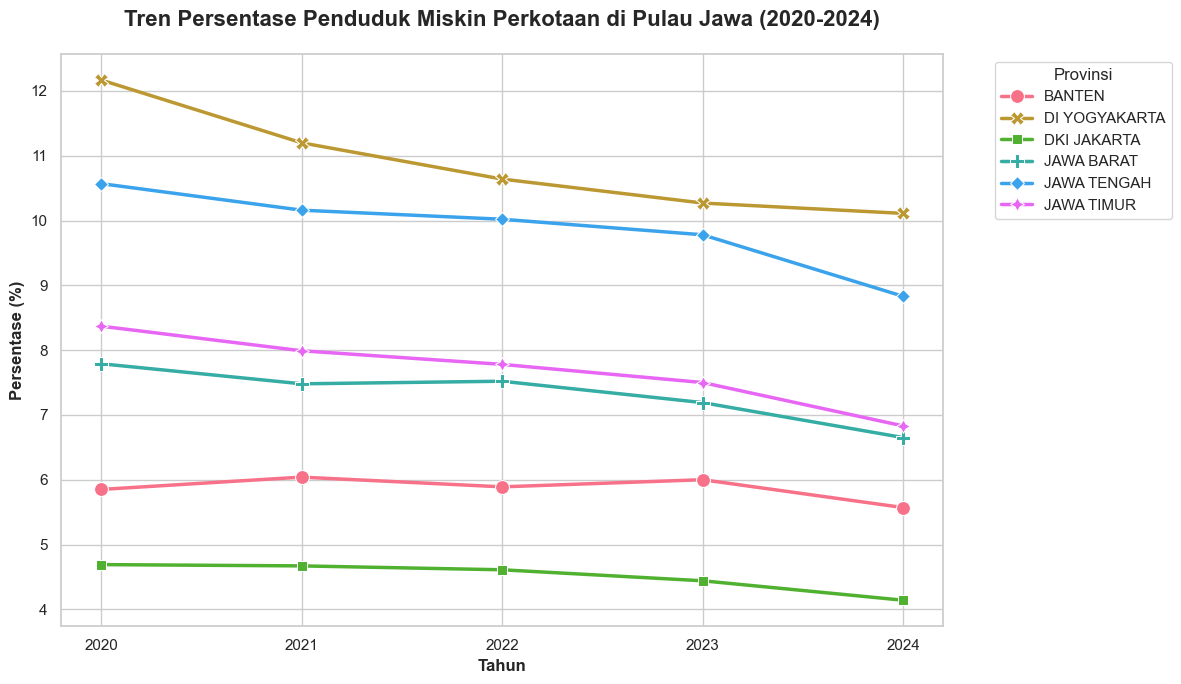

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Prepare the data for plotting
# We need to flip the table so Years are rows and Provinces are columns
df_plot = final_comparison.set_index('Provinsi').T

# Clean the index (remove 'Garis_Kemiskinan_') so only the year remains
df_plot.index = [idx.split('_')[-1] for idx in df_plot.index]

# 2. Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# 3. Plotting
# Use a nice color palette and distinct markers for each province
palette = sns.color_palette("husl", len(jawa))
ax = sns.lineplot(data=df_plot, dashes=False, markers=True, markersize=10, linewidth=2.5, palette=palette)

# 4. Customizing the Aesthetics
plt.title('Tren Persentase Penduduk Miskin Perkotaan di Pulau Jawa (2020-2024)', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Tahun', fontsize=12, fontweight='bold')
plt.ylabel('Persentase (%)', fontsize=12, fontweight='bold')

# Format Y-axis to show thousands separator (e.g., 500,000)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Place the legend outside the plot so it doesn't overlap lines
plt.legend(title='Provinsi', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

In [38]:
import json
import csv

# Path to your actual csv file
file_path = '/ppo_jabar_2025.csv' 

poverty_data = []

# Using 'with' ensures the file is closed automatically
with open(data_dir + file_path, mode='r', encoding='utf-8') as f:
    reader = csv.reader(f)

    for row in reader:
        # 1. Skip empty rows or rows that don't have at least 2 columns
        if len(row) < 2 or not row[0].strip() or not row[1].strip():
            continue
        
        name = row[0].strip()
        
        # 2. Skip the "Provinsi" summary row and headers
        # We only want the specific regencies (Kabupaten/Kota)
        if "Provinsi" in name or "Kabupaten/Kota" in name:
            continue
            
        try:
            # 3. Clean the string and convert to float
            # Some CSVs use commas for decimals, so we replace them if necessary
            rate_str = row[1].replace(',', '.')
            rate = float(rate_str)
            
            poverty_data.append({
                "region": name,
                "poverty_rate": rate
            })
        except ValueError:
            # Skip rows where the second column isn't a valid number
            continue

# 4. Save to a JSON file
output_file = '/ppo_jabar_2025.json'
with open(data_dir + output_file, 'w', encoding='utf-8') as json_f:
    json.dump(poverty_data, json_f, indent=4)

print(f"Successfully converted {len(poverty_data)} regions to {output_file}")

Successfully converted 27 regions to /ppo_jabar_2025.json


In [ ]:
# ==========================================
# PETA KEMISKINAN JAWA BARAT 2025 (Plotly)
# File data: ppo_jabar_2025.json
# ==========================================

import json
import pandas as pd
import requests
import plotly.express as px

# ------------------------------------------
# 1. LOAD DATA JSON
# ------------------------------------------
# Format expected:
# [
#   {"region":"Kabupaten Bandung", "poverty_rate":7.21},
#   {"region":"Kota Bandung", "poverty_rate":3.85}
# ]

with open("../data/ppo_jabar_2025.json", "r", encoding="utf-8") as f:
    poverty_data = json.load(f)

df = pd.DataFrame(poverty_data)

print("Preview Data:")
print(df.head())


# ------------------------------------------
# 2. LOAD INDONESIA REGENCY/CITY GEOJSON
# ------------------------------------------
geojson_url = "https://raw.githubusercontent.com/superpikar/indonesia-geojson/master/indonesia-kabupaten-kota.geojson"
geojson = requests.get(geojson_url).json()


# ------------------------------------------
# 3. FILTER ONLY WEST JAVA AREAS
# ------------------------------------------
# GeoJSON property usually NAME_1 = province
west_java_features = []

for feature in geojson["features"]:
    props = feature["properties"]
    
    if props.get("NAME_1", "").lower() in [
        "jawa barat",
        "west java"
    ]:
        west_java_features.append(feature)

west_java_geojson = {
    "type": "FeatureCollection",
    "features": west_java_features
}


# ------------------------------------------
# 4. CREATE CHOROPLETH MAP
# ------------------------------------------
fig = px.choropleth(
    df,
    geojson=west_java_geojson,
    locations="region",
    featureidkey="properties.NAME_2",
    color="poverty_rate",
    color_continuous_scale="Reds",
    range_color=(0, df["poverty_rate"].max()),
    labels={"poverty_rate": "Kemiskinan (%)"},
    title="Peta Tingkat Kemiskinan Jawa Barat 2025"
)


# ------------------------------------------
# 5. IMPROVE MAP VIEW
# ------------------------------------------
fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.update_layout(
    margin={"r":0, "t":50, "l":0, "b":0},
    width=1000,
    height=700
)


# ------------------------------------------
# 6. SHOW MAP
# ------------------------------------------
fig.show()

Preview Data:
     region  poverty_rate
0     Bogor          6.26
1  Sukabumi          6.41
2   Cianjur          9.82
3   Bandung          6.04
4     Garut          9.39


JSONDecodeError: Extra data: line 1 column 4 (char 3)

In [41]:
import requests
geo = requests.get(geojson_url).json()

print(geo['features'][0]['properties'])

JSONDecodeError: Extra data: line 1 column 4 (char 3)